24BAD128 - EXP 7 Scenario 1
First 5 rows:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


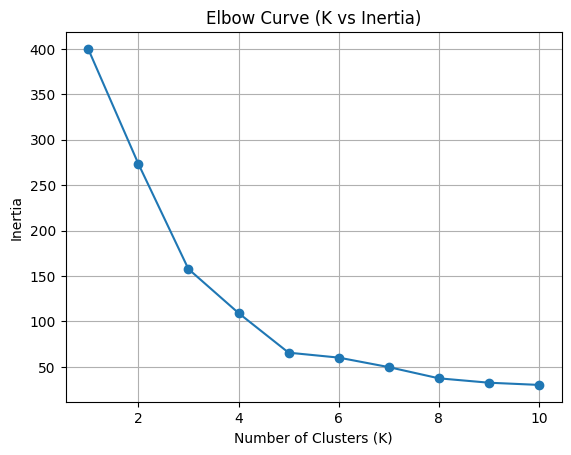


Evaluation Metrics:
Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


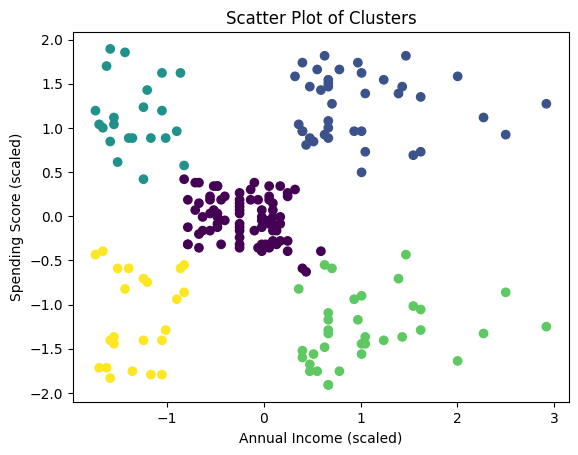

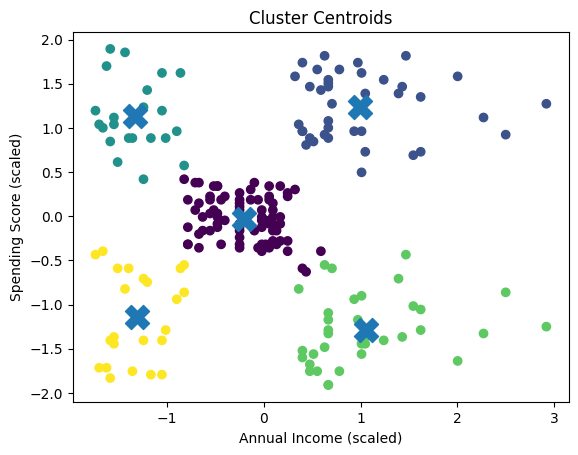


Cluster-wise Mean Values:
         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
0         86.320988  42.716049           55.296296               49.518519
1        162.000000  32.692308           86.538462               82.128205
2         23.090909  25.272727           25.727273               79.363636
3        164.371429  41.114286           88.200000               17.114286
4         23.000000  45.217391           26.304348               20.913043


In [2]:
#24BAD128 - EXP 7 Scenario 1

#from google.colab import files
#uploaded = files.upload()

print("24BAD128 - EXP 7 Scenario 1")
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df = pd.read_csv("Mall_Customers.csv")

print("First 5 rows:")
print(df.head())

#Select relevant features
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

#Handle missing values
X = X.dropna()

#Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#Elbow Method(Find optimal K)
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot Elbow Curve
plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Curve (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid()
plt.show()

# Apply K-Means(choose K = 5)
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = labels

# Evaluation Metrics
sil_score = silhouette_score(X_scaled, labels)

print("\nEvaluation Metrics:")
print("Inertia:", kmeans.inertia_)
print("Silhouette Score:", sil_score)

#Visualization - Scatter Plot
plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

plt.title("Scatter Plot of Clusters")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

#Visualization - Centroids
centroids = kmeans.cluster_centers_

plt.figure()
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels)

# Plot centroids
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=300, marker='X')

plt.title("Cluster Centroids")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.show()

#Cluster Interpretation
print("\nCluster-wise Mean Values:")
print(df.groupby('Cluster').mean(numeric_only=True))


24BAD128 - EXP 7 Scenario 2
Dataset Loaded!

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


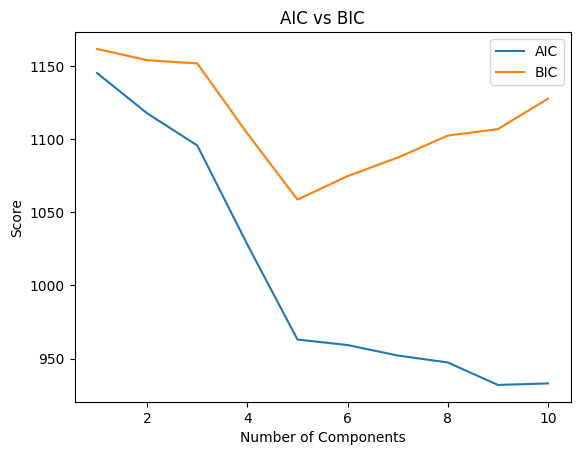


Cluster Probabilities (first 5 rows):

[[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score: 0.5536892843811245


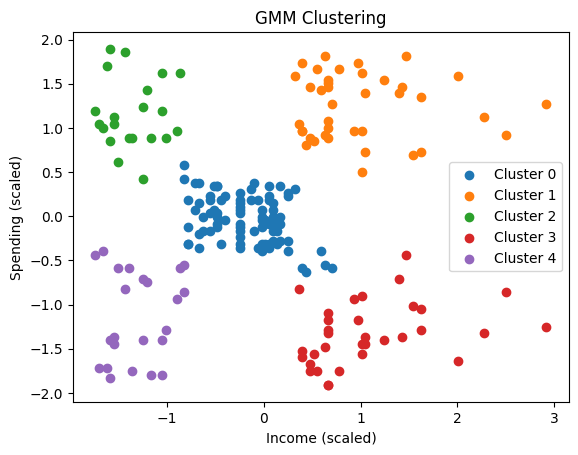

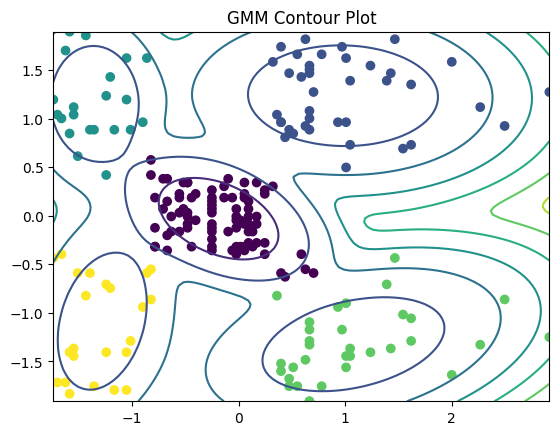

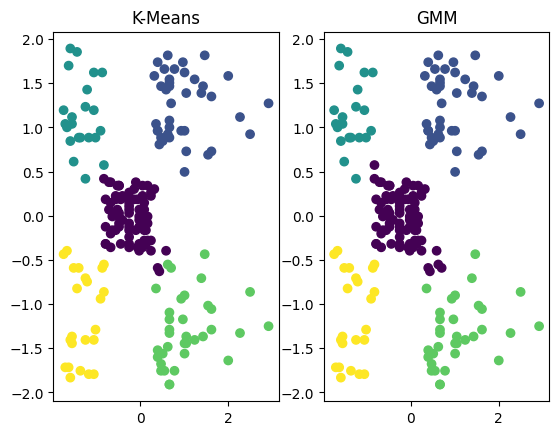


GMM Cluster Means:

                   Age  Annual Income (k$)  Spending Score (1-100)
GMM_Cluster                                                       
0            42.714286           55.642857               49.369048
1            32.692308           86.538462               82.128205
2            25.333333           25.095238               80.047619
3            40.454545           88.818182               16.000000
4            45.217391           26.304348               20.913043


In [4]:
#24BAD128 - EXP 7 Scenario 2

#from google.colab import files
#uploaded = files.upload()

print("24BAD128 - EXP 7 Scenario 2")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

data = pd.read_csv("Mall_Customers (1).csv")

print("Dataset Loaded!\n")
print(data.head())


print("\nMissing Values:\n", data.isnull().sum())

# Drop unwanted columns
data = data.drop(['CustomerID', 'Gender'], axis=1)

# Select features

X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

aic = []
bic = []

k_range = range(1, 11)

for k in k_range:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(X_scaled)
    aic.append(gmm.aic(X_scaled))
    bic.append(gmm.bic(X_scaled))

# Plot AIC & BIC

plt.figure()

plt.plot(k_range, aic, label='AIC')
plt.plot(k_range, bic, label='BIC')
plt.xlabel("Number of Components")
plt.ylabel("Score")
plt.title("AIC vs BIC")
plt.legend()
plt.show()

k_optimal = 5

gmm = GaussianMixture(n_components=k_optimal, random_state=42)
gmm.fit(X_scaled)

probabilities = gmm.predict_proba(X_scaled)

print("\nCluster Probabilities (first 5 rows):\n")
print(probabilities[:5])

clusters = np.argmax(probabilities, axis=1)
data['GMM_Cluster'] = clusters

print("\nLog-Likelihood:", gmm.score(X_scaled))
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))
print("Silhouette Score:", silhouette_score(X_scaled, clusters))

plt.figure()

for i in range(k_optimal):
    plt.scatter(
        X_scaled[clusters == i, 0],
        X_scaled[clusters == i, 1],
        label=f'Cluster {i}'
    )

plt.title("GMM Clustering")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")
plt.legend()
plt.show()

x = np.linspace(X_scaled[:,0].min(), X_scaled[:,0].max(), 100)
y = np.linspace(X_scaled[:,1].min(), X_scaled[:,1].max(), 100)

X_grid, Y_grid = np.meshgrid(x, y)

XX = np.array([X_grid.ravel(), Y_grid.ravel()]).T

Z = -gmm.score_samples(XX)
Z = Z.reshape(X_grid.shape)

plt.figure()
plt.contour(X_grid, Y_grid, Z)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("GMM Contour Plot")
plt.show()

kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

plt.figure()
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("K-Means")
plt.subplot(1,2,2)
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=clusters)
plt.title("GMM")
plt.show()


print("\nGMM Cluster Means:\n")
print(data.groupby('GMM_Cluster').mean())
